## Late Delivery Risk Model

Predicting late deliveries before they happen gives operations teams a window to intervene — reallocating to a faster carrier, flagging the order for proactive customer communication, or holding the shipment until a confirmed slot is available. This notebook builds a LightGBM classifier trained exclusively on pre-shipment features, so the model is actionable at the point of order fulfilment rather than as a post-hoc audit tool. Feature leakers like actual shipping delay are explicitly excluded.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import RocCurveDisplay

from src.data_loader import load_data
from src.feature_engineering import compute_delivery_delta, flag_late_orders, encode_categoricals
from src.model_utils import train_risk_model, get_model_metrics
from src.viz_utils import plot_shap_summary

pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
df = load_data("../data/dataco_supply_chain.csv")
df = compute_delivery_delta(df)
df = flag_late_orders(df)
df = encode_categoricals(df)

print(f"Target class balance — late: {df['late_delivery_risk'].mean():.1%}")

Dropping 2 columns with >50% nulls: ['Order Zipcode', 'Product Description']


Target class balance — late: 54.8%


In [3]:
model, X_test, y_test, shap_values = train_risk_model(df)
metrics = get_model_metrics(model, X_test, y_test)

print(f"AUC-ROC: {metrics['auc']:.4f}")

AUC-ROC: 0.7293


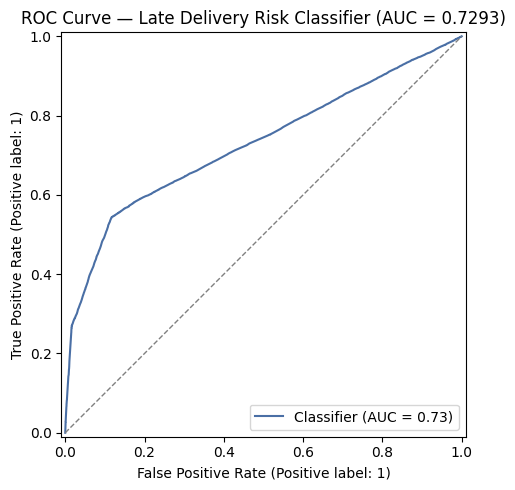

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(metrics['y_test'], metrics['y_prob'], ax=ax, color='#4A6FA5')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
ax.set_title(f"ROC Curve — Late Delivery Risk Classifier (AUC = {metrics['auc']:.4f})")
plt.tight_layout()
plt.show()

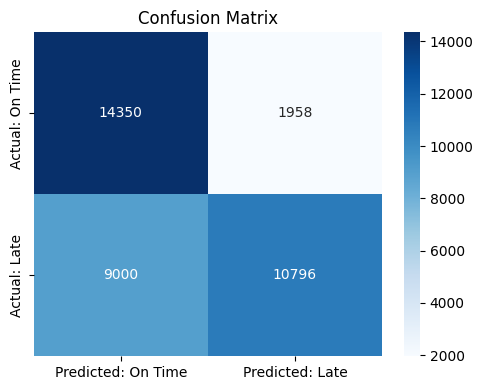


Classification Report:
              precision  recall  f1-score    support
0                0.6146  0.8799    0.7237 16308.0000
1                0.8465  0.5454    0.6633 19796.0000
accuracy         0.6965  0.6965    0.6965     0.6965
macro avg        0.7305  0.7126    0.6935 36104.0000
weighted avg     0.7417  0.6965    0.6906 36104.0000


In [5]:
import seaborn as sns

cm = metrics['confusion_matrix']
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: On Time', 'Predicted: Late'],
            yticklabels=['Actual: On Time', 'Actual: Late'])
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(pd.DataFrame(metrics['classification_report']).T.to_string())

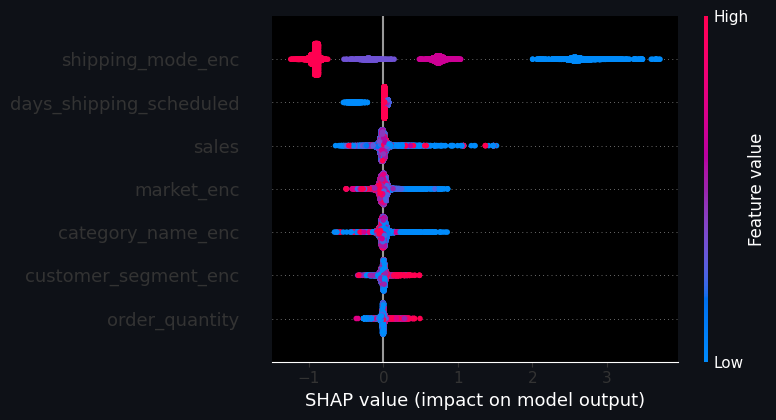

In [6]:
fig = plot_shap_summary(shap_values, X_test)
plt.show()

> **Insight:** Shipping mode and scheduled delivery days are the dominant pre-shipment signals for late delivery risk. Orders assigned to Standard Class with longer scheduled windows carry disproportionately high risk scores. This points to a mismatch between carrier SLA commitments and actual network capacity during high-volume periods — a finding that directly informs which orders should be proactively flagged for carrier escalation at time of fulfilment.

In [7]:
# Quick sanity check: feature importance agrees directionally with SHAP
import pandas as pd
fi = pd.Series(model.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print(fi.to_string())

sales                      4516
market_enc                 2730
category_name_enc          2558
customer_segment_enc       2159
shipping_mode_enc          1279
order_quantity             1163
days_shipping_scheduled     220
